In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/Hst1_self_asso/analysis/dimer/res-res/'

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue', 'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

In [8]:
seq = 'DSHEKRHHGYRRKFHEKHHSHREFPFYGDYGSNYLYDN'
residues = seq*4
chains = [range(0, 38), range(38, 76), range(76, 114), range(114, 152)]
combined = list(chains[0]) + list(chains[1]) + list(chains[2]) + list(chains[3])
intra_pairs = []
inter_pairs = []

for chain in chains:
    for res in chain:
        for entry in combined:
            labels = sorted([residues[res], residues[entry]])
            pair = labels[0] + '-' + labels[1]
            
            if res == entry:
                continue     
            elif entry in chain:
                d = np.genfromtxt((work_dir + 'Res' + str(res) + '/' + str(res) + '_' + str(entry) + '.xvg'), 
                          usecols=(1), unpack=True, skip_header=24)
                intra_pairs.append((pair, (sum(d)/len(d))))
            else:
                d = np.genfromtxt((work_dir + 'Res' + str(res) + '/' + str(res) + '_' + str(entry) + '.xvg'), 
                          usecols=(1), unpack=True, skip_header=24)
                inter_pairs.append((pair, (sum(d)/len(d))))

In [11]:
def averaging_function(pairs):
    unique_pairs = []
    for pair in pairs:
        if pair[0] not in unique_pairs:
            unique_pairs.append(pair[0])
    dist_array = np.zeros(len(unique_pairs))
    
    counter1 = 0
    for ref_pair in unique_pairs:
        counter2 = 0
        for sel_pair in pairs:
            if ref_pair == sel_pair[0]:
                dist_array[counter1] += sel_pair[1]
                counter2 += 1
        dist_array[counter1] = dist_array[counter1]/counter2
        counter1 += 1    
    return unique_pairs, dist_array 

In [12]:
salt_bridges = [
    'D-K', 'D-R',
    'E-K', 'E-R'
]

charge_repulsion = [
    'D-D', 'D-E', 'E-E',
    'K-K', 'K-R', 'R-R'
]

hydrogen_bonding = [
    'D-S', 'D-H', 'D-N',
    'E-S', 'E-H', 'E-N',
    'S-S', 'H-S', 'N-S',
    'H-H', 'H-N', 'N-N',
    'K-S', 'K-H', 'K-N',
    'R-S', 'R-H', 'R-N',
    'H-Y'
]

pi_pi_stacking = [
    'F-F',
    'F-Y',
    'Y-Y'
]

cation_pi = [
    'F-K', 'K-Y',
    'F-R', 'R-Y'
]

hydrophobic_contacts = [
    'G-G', 'G-P', 'G-L',
    'P-P', 'L-P', 'L-L',
    'F-G', 'F-P', 'F-L',
    'G-Y', 'P-Y', 'L-Y'
]

interactions = []
interactions.append(salt_bridges)
interactions.append(charge_repulsion)
interactions.append(hydrogen_bonding)
interactions.append(pi_pi_stacking)
interactions.append(cation_pi)
interactions.append(hydrophobic_contacts)

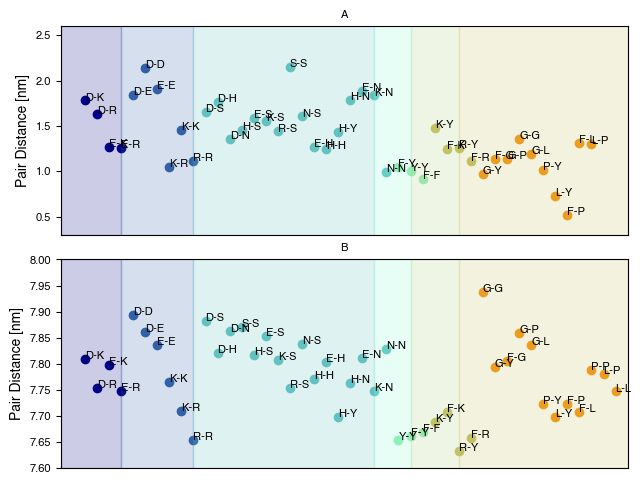

In [13]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=((16*cm), (12*cm)), layout='constrained')
p_intra, d_intra = averaging_function(intra_pairs)
p_inter, d_inter = averaging_function(inter_pairs)

def plot_func(pairs, dists, axis):
    ticks = []
    counter = 0
    for interaction in interactions:
        average = 0
        count = 0
        for (p, d) in zip(pairs, dists):
            if p in interaction:
                ax[axis].scatter(p, d, color=color_list[counter])
                ax[axis].text(p, d, str(p), fontsize=font)
                average += d
                count += 1
        counter += 19
        ticks.append(str(average/count)[0:4])
    ax[axis].set_xticks([])
    #ax[axis].set_xticks([1, 6, 16.5, 25.5, 29, 37.5])
    #ax[axis].set_xticklabels(ticks)
    ax[axis].tick_params(labelsize=font)
    ax[axis].set_ylabel('Pair Distance [nm]', fontsize=font_label)
    ax[axis].axvspan(-2, 3, color=color_list[0], alpha=0.2)
    ax[axis].axvspan(3, 9, color=color_list[19], alpha=0.2)
    ax[axis].axvspan(9, 24, color=color_list[37], alpha=0.2)
    ax[axis].axvspan(24, 27, color=color_list[51], alpha=0.2)
    ax[axis].axvspan(27, 31, color=color_list[69], alpha=0.2)
    ax[axis].axvspan(31, 45, color=color_list[77], alpha=0.2)

plot_func(p_intra, d_intra, 0)
plot_func(p_inter, d_inter, 1)
ax[0].set_title('A', fontsize=font)
ax[0].set_ylim(0.3, 2.6)
ax[0].set_xlim(-2, 45)
ax[1].set_title('B', fontsize=font)
ax[1].set_ylim(7.6, 8.0)
ax[1].set_xlim(-2, 45)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Interactive_patterns.pdf', dpi=1000)